# Statistics for Machine Learning

This notebook applies statistical ideas to common machine-learning workflows: data inspection, scaling, sampling, cross-validation, classification metrics, bootstrap uncertainty, correlation, and model evaluation.


## 1. Setup


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## 2. Create a Small Dataset


In [2]:
df = pd.DataFrame({
    "age": [21, 25, 29, 31, 45, 52, 28, 34],
    "income": [25000, 32000, 41000, 45000, 90000, 110000, 38000, 52000],
    "support_calls": [2, 3, 1, 4, 8, 10, 2, 5],
    "churn": [0, 0, 0, 1, 1, 1, 0, 1]
})

print(df)


   age  income  support_calls  churn
0   21   25000              2      0
1   25   32000              3      0
2   29   41000              1      0
3   31   45000              4      1
4   45   90000              8      1
5   52  110000             10      1
6   28   38000              2      0
7   34   52000              5      1


## 3. Descriptive Statistics


In [3]:
print(df.describe())


             age         income  support_calls     churn
count   8.000000       8.000000       8.000000  8.000000
mean   33.125000   54125.000000       4.375000  0.500000
std    10.412047   29921.027007       3.159453  0.534522
min    21.000000   25000.000000       1.000000  0.000000
25%    27.250000   36500.000000       2.000000  0.000000
50%    30.000000   43000.000000       3.500000  0.500000
75%    36.750000   61500.000000       5.750000  1.000000
max    52.000000  110000.000000      10.000000  1.000000


## 4. Mean, Median, and Standard Deviation


In [4]:
for column in ["age", "income", "support_calls"]:
    print("\n", column)
    print("Mean:", df[column].mean())
    print("Median:", df[column].median())
    print("Std:", df[column].std())



 age
Mean: 33.125
Median: 30.0
Std: 10.412046594484405

 income
Mean: 54125.0
Median: 43000.0
Std: 29921.02700682009

 support_calls
Mean: 4.375
Median: 3.5
Std: 3.1594529363709247


## 5. Z-Score Standardisation

For each feature:

$$
z=\frac{x-\mu}{\sigma}
$$


In [5]:
features = df[["age", "income", "support_calls"]]
standardised = (features - features.mean()) / features.std(ddof=0)
print(standardised)


        age    income  support_calls
0 -1.244920 -1.040604      -0.803614
1 -0.834225 -0.790502      -0.465250
2 -0.423530 -0.468942      -1.141978
3 -0.218182 -0.326026      -0.126886
4  1.219252  1.281774       1.226569
5  1.937969  1.996352       1.903297
6 -0.526204 -0.576128      -0.803614
7  0.089840 -0.075924       0.211477


## 6. Min-Max Scaling

$$
x'=\frac{x-x_{min}}{x_{max}-x_{min}}
$$


In [6]:
minmax = (features - features.min()) / (features.max() - features.min())
print(minmax)


        age    income  support_calls
0  0.000000  0.000000       0.111111
1  0.129032  0.082353       0.222222
2  0.258065  0.188235       0.000000
3  0.322581  0.235294       0.333333
4  0.774194  0.764706       0.777778
5  1.000000  1.000000       1.000000
6  0.225806  0.152941       0.111111
7  0.419355  0.317647       0.444444


## 7. Correlation Matrix


In [7]:
corr = df.corr(numeric_only=True)
print(corr)


                    age    income  support_calls     churn
age            1.000000  0.994085       0.940725  0.757220
income         0.994085  1.000000       0.949960  0.719044
support_calls  0.940725  0.949960       1.000000  0.803614
churn          0.757220  0.719044       0.803614  1.000000


## 8. Visualise a Distribution


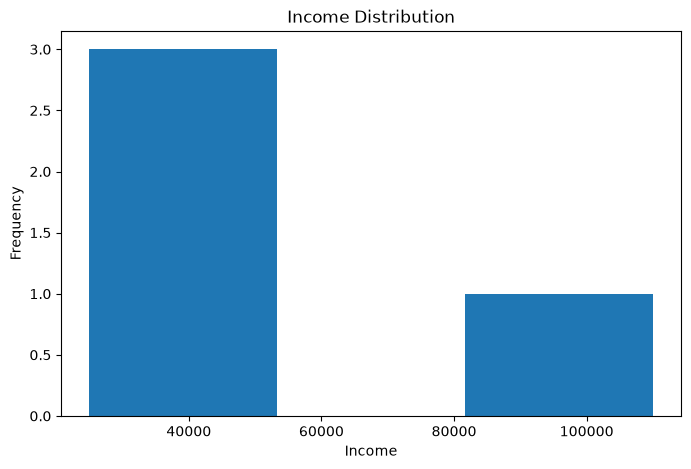

In [8]:
plt.figure(figsize=(8, 5))
plt.hist(df["income"], bins=6)
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.title("Income Distribution")
plt.show()


## 9. Train/Test Split and Scaling Without Leakage


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df[["age", "income", "support_calls"]]
y = df["churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))


Training rows: 6
Test rows: 2


## 10. Cross-Validation


In [10]:
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

X_reg, y_reg = load_diabetes(return_X_y=True)
model = LinearRegression()

scores = cross_val_score(
    model,
    X_reg,
    y_reg,
    cv=5,
    scoring="neg_mean_squared_error"
)

mse_scores = -scores
print("Fold MSE:", mse_scores)
print("Mean CV MSE:", mse_scores.mean())


Fold MSE: [2779.92344921 3028.83633883 3237.6875877  3008.74648884 2910.21268776]
Mean CV MSE: 2993.0813104693307


## 11. Bootstrap Mean and Standard Error


In [11]:
rng = np.random.default_rng(42)
data = np.array([12, 15, 14, 18, 21, 16, 17, 13])

bootstrap_means = []
for _ in range(5000):
    sample = rng.choice(data, size=len(data), replace=True)
    bootstrap_means.append(sample.mean())

bootstrap_means = np.array(bootstrap_means)

print("Original mean:", data.mean())
print("Bootstrap mean:", bootstrap_means.mean())
print("Bootstrap standard error:", bootstrap_means.std(ddof=1))


Original mean: 15.75
Bootstrap mean: 15.74865
Bootstrap standard error: 0.9643698353514938


## 12. Bootstrap Distribution


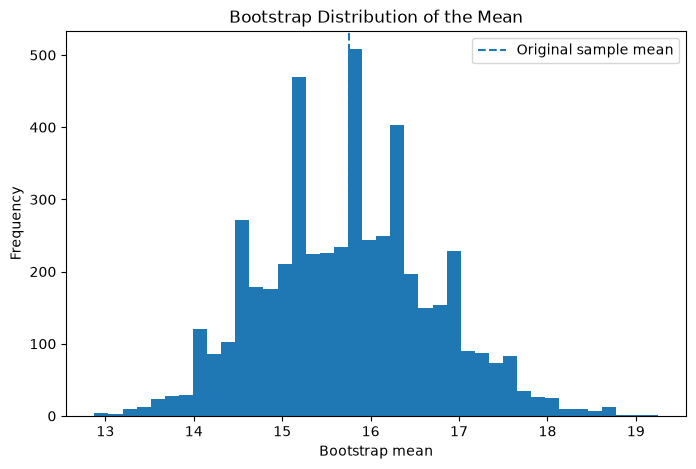

In [12]:
plt.figure(figsize=(8, 5))
plt.hist(bootstrap_means, bins=40)
plt.axvline(data.mean(), linestyle="--", label="Original sample mean")
plt.xlabel("Bootstrap mean")
plt.ylabel("Frequency")
plt.title("Bootstrap Distribution of the Mean")
plt.legend()
plt.show()


## 13. Classification Metrics and Class Imbalance


In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

y_true = [0, 0, 1, 1, 1, 0, 1, 0]
y_pred = [0, 1, 1, 1, 0, 0, 1, 0]

print("Confusion matrix:\n", confusion_matrix(y_true, y_pred))
print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))
print("F1:", f1_score(y_true, y_pred))


Confusion matrix:
 [[3 1]
 [1 3]]
Accuracy: 0.75
Precision: 0.75
Recall: 0.75
F1: 0.75


## 14. Extreme Class-Imbalance Example


In [14]:
# 20 positives and 980 negatives; a classifier predicts every observation as negative.
tp, tn, fp, fn = 0, 980, 0, 20
accuracy = (tp + tn) / (tp + tn + fp + fn)
recall = tp / (tp + fn)

print("Accuracy:", accuracy)
print("Recall:", recall)


Accuracy: 0.98
Recall: 0.0


## 15. Regression Error Metrics


In [15]:
actual = np.array([100, 120, 140, 160, 180])
predicted = np.array([105, 115, 150, 155, 170])

errors = actual - predicted
mae = np.mean(np.abs(errors))
mse = np.mean(errors**2)
rmse = np.sqrt(mse)

print("Errors:", errors)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)


Errors: [ -5   5 -10   5  10]
MAE: 7.0
MSE: 55.0
RMSE: 7.416198487095663


## 16. Residual Analysis


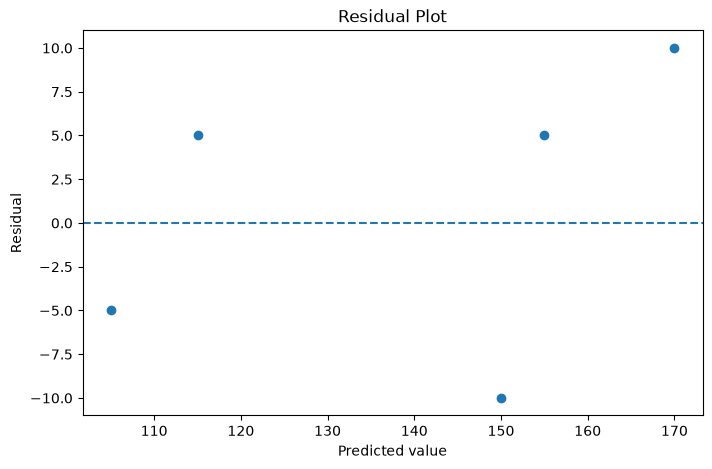

In [16]:
plt.figure(figsize=(8, 5))
plt.scatter(predicted, errors)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted value")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()


## 17. Probability Thresholds

Suppose a classifier produces probabilities. The classification threshold changes the precision-recall trade-off.


In [17]:
probabilities = np.array([0.05, 0.20, 0.35, 0.55, 0.65, 0.80, 0.90])

for threshold in [0.3, 0.5, 0.7]:
    predictions = (probabilities >= threshold).astype(int)
    print("Threshold:", threshold, "Predictions:", predictions)


Threshold: 0.3 Predictions: [0 0 1 1 1 1 1]
Threshold: 0.5 Predictions: [0 0 0 1 1 1 1]
Threshold: 0.7 Predictions: [0 0 0 0 0 1 1]


## 18. Practical Exercises

1. Calculate the mean, median, and standard deviation of a numeric feature.
2. Identify a potentially skewed feature and explain why the mean and median differ.
3. Standardise a feature using training-set statistics.
4. Demonstrate why fitting a scaler separately on the test set is incorrect.
5. Calculate and interpret a correlation matrix.
6. Construct an imbalanced classification example where accuracy is misleading.
7. Calculate precision, recall, and F1 from a confusion matrix.
8. Use five-fold cross-validation to compare two regression models.
9. Bootstrap a sample mean and estimate its standard error.
10. Plot residuals and identify any visible structure.
11. Compare model performance using MAE and RMSE.
12. Change a classification threshold and observe precision and recall.
13. Create a small example of sampling bias and explain how it could affect a model.
14. Simulate a change in the feature distribution between training and deployment data.
15. Write a short statistical report explaining whether a model evaluation is trustworthy.


## 19. Final Checklist

Before trusting a machine-learning result, ask:

- What population does the dataset represent?
- Is the sample representative?
- Are measurements reliable?
- Are there important missing values or outliers?
- Was preprocessing fitted only on training data?
- Is there any data leakage?
- Are the train and test distributions comparable?
- Is class imbalance present?
- Are the chosen metrics appropriate?
- Are probability predictions calibrated if needed?
- Was cross-validation or another suitable validation method used?
- Is uncertainty in the performance estimate understood?
- Is the observed effect practically important?
- Could the relationship be associative rather than causal?
- Could deployment data have a different distribution?
